
## Exercise - Analyse Weekday and Weekend Patterns Using PCA Scores
Your task is to use the PCA scores to check whether weekdays and weekends show different patterns in the reduced PCA space.

Use the already created and `scores` and `df["is_weekend"]` for this task.

- Create a new DataFrame called `score_analysis` that contains `PC1`, `PC2`, and `is_weekend`.
- Calculate the average `PC1` and `PC2` score separately for weekdays and weekends (`is_weekend = 1`).
- Create a scatter plot with `PC1` on the x-axis and `PC2` on the y-axis. Use different colors for weekdays and weekends.

---

### Questions

1. What is the average `PC1` score for weekdays? 
2. What is the average `PC1` score for weekends?
3. What is the average `PC2` score for weekdays?
4. What is the average `PC2` score for weekends?
5. Which component separates weekdays and weekends more clearly: `PC1` or `PC2`?
6. What does this tell us about using PCA scores for energy data analysis?

### Answers
1. The average `PC1` score for weekdays is approximately **-0.431**.
2. The average `PC1` score for weekends is approximately **1.087**.
3. The average `PC2` score for weekdays is approximately **0.462**.
4. The average `PC2` score for weekends is approximately **-1.164**.
5. `PC2` separates weekdays and weekends more clearly. The difference between weekday and weekend averages is larger for `PC2`:
   - PC1 difference: about `1.52`
   - PC2 difference: about `1.63`
   The scatter plot also shows that weekend points are mostly lower on the `PC2` axis, while weekday points are generally higher.
6. This shows that PCA scores can reveal different energy-consumption patterns, such as weekday and weekend behaviour. Even though PCA does not use the weekend label directly, the reduced components still capture structure in the daily load profiles.


In [1]:
# Imports
import datetime
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [2]:
# PREASSEMBLE FROM EXISTING LAB NOTEBOOK

rng = np.random.default_rng(42)

start = "2024-01-01"
end = "2024-12-31 23:00"
idx_h = pd.date_range(start, end, freq="h")
n = len(idx_h)

doy = idx_h.day_of_year.to_numpy()
hour = idx_h.hour.to_numpy()
dow = idx_h.dayofweek.to_numpy()

t_out = 6 + 12*np.sin(2*np.pi*(doy-30)/365) + rng.normal(0, 2, n)

wind = 3 + 1.2*np.sin(2*np.pi*(dow)/7) + rng.normal(0, 0.8, n)
wind = np.clip(wind, 0, None)

workday = (dow < 5).astype(float)
weekend = 1 - workday
morning_bump = np.exp(-0.5*((hour-9)/2.5)**2)
evening_peak = np.exp(-0.5*((hour-19)/2.8)**2)
night = ((hour <= 6) | (hour >= 23)).astype(float)

pv_midday = np.exp(-0.5*((hour-12)/3.0)**2)
pv_season = 0.6 + 0.4*np.sin(2*np.pi*(doy-80)/365)
pv_kw = 3.5 * pv_midday * np.clip(pv_season, 0, None)
pv_kw *= np.clip(1 + rng.normal(0, 0.08, n), 0, None)

daily_level = 0.12 + 0.02*np.sin(2*np.pi*(doy)/14) + rng.normal(0, 0.01, n)
tou = 0.02*((hour >= 8) & (hour <= 11)) + 0.03*((hour >= 17) & (hour <= 21))
price = np.clip(daily_level + tou, 0.05, None)

base = 0.9 + 0.15*workday + 0.05*weekend
shape = 0.35*morning_bump + 0.55*evening_peak + 0.1*night
temp_effect = 0.03*np.maximum(20 - t_out, 0) + 0.02*np.maximum(t_out - 24, 0)
price_shift = -0.12*tou*price
pv_self_cons = -0.25*pv_kw
noise = rng.normal(0, 0.08, n)

load_kwh = np.clip(
    base + shape + temp_effect + price_shift + pv_self_cons + noise,
    0.05,
    None
)

df_h = pd.DataFrame({
    "ts": idx_h,
    "load": load_kwh,
    "t_out": t_out,
    "wind": wind,
    "price": price,
    "pv": pv_kw,
    "dow": dow,
})

df_h["date"] = df_h["ts"].dt.date
df_h["hour"] = df_h["ts"].dt.hour

wide = df_h.pivot_table(index="date", columns="hour", values="load")
wide.columns = [f"h{h}" for h in wide.columns]

extras = df_h.groupby("date").agg(
    t_mean=("t_out", "mean"),
    wind=("wind", "mean"),
    price=("price", "mean"),
)

df = wide.join(extras)
df.index = pd.to_datetime(df.index)

df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

features = [f"h{h}" for h in range(24)] + ["t_mean", "wind", "price"]

X = df[features].copy()

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.9, svd_solver="full"))
])

X_pca = pipe.fit_transform(X)
pca = pipe.named_steps["pca"]

scores = pd.DataFrame(
    X_pca,
    index=df.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

In [8]:
score_analysis = scores[["PC1", "PC2"]].copy()
score_analysis["is_weekend"] = df["is_weekend"]
score_analysis.head()

,PC1,PC2,is_weekend
date,,,
2024-01-01,-4.421815,0.321761,0
2024-01-02,-4.008287,0.986249,0
2024-01-03,-4.714001,1.277793,0
2024-01-04,-4.058636,0.719215,0
2024-01-05,-4.437467,-0.279013,0


In [9]:
score_analysis.groupby("is_weekend")[["PC1", "PC2"]].mean()

,PC1,PC2
is_weekend,,
0,-0.431451,0.462181
1,1.086924,-1.164340


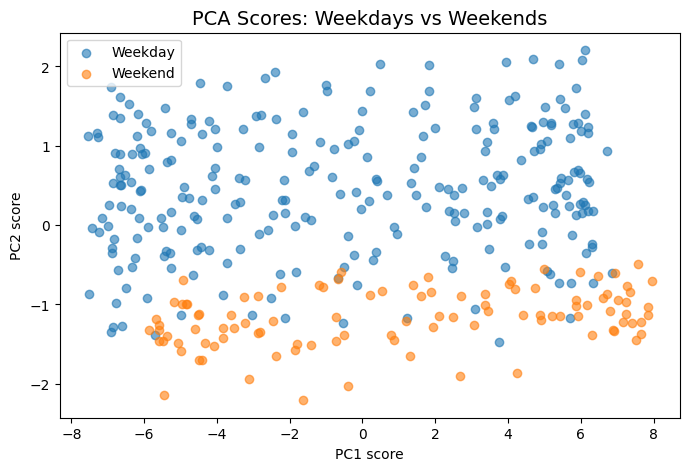

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(
    score_analysis[score_analysis["is_weekend"] == 0]["PC1"],
    score_analysis[score_analysis["is_weekend"] == 0]["PC2"],
    label="Weekday",
    alpha=0.6
)

plt.scatter(
    score_analysis[score_analysis["is_weekend"] == 1]["PC1"],
    score_analysis[score_analysis["is_weekend"] == 1]["PC2"],
    label="Weekend",
    alpha=0.6
)

plt.title("PCA Scores: Weekdays vs Weekends", fontsize=14)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.legend()
plt.show()